In [14]:
from pathlib import Path
import numpy as np
import pandas as pd

# ==========================================
# Paths
# ==========================================
BASE_DIR = Path(".").resolve()

# Update this if your signal file has another name
SIGNAL_FILE = BASE_DIR / "quality_signals_eb" / "firm_year_quality_signals_eb.csv"

# stock_prices is outside current folder
PRICE_FILE = BASE_DIR.parent / "stock_prices" / "all_stock_prices.csv"

OUT_DIR = BASE_DIR / "portfolio_results_equal_weighted"
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [15]:

# ==========================================
# 1. Load signals
# ==========================================
signals = pd.read_csv(SIGNAL_FILE)
signals["FormationYear"] = pd.to_numeric(signals["FormationYear"], errors="coerce")
signals["Year"] = pd.to_numeric(signals["Year"], errors="coerce")

# Keep only years you want
signals = signals[
    (signals["FormationYear"] >= 2010) &
    (signals["FormationYear"] <= 2025)
].copy()

print("Signals shape:", signals.shape)
display(signals.head())


Signals shape: (7292, 38)


,Year,Ticker,CompanyName,Industry,Sector,PROF,REVT,COGS,XSGA_COMPONENTS,XRD,...,p_q5,sort_signal_m1,sort_signal_m2,sort_signal_m3,rank_m1,rank_m2,rank_m3,q_m1,q_m2,q_m3
0,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.00,168.59,0.00,...,5.227990e-04,-0.528651,-0.273844,5.227990e-04,0.042345,0.039088,0.123779,1,1,1
1,2009,AAK.ST,AAK AB (publ),Food & Tobacco,Consumer Staples,0.452191,13153.20,9482.61,2456.66,0.00,...,4.886940e-01,0.452191,0.355993,4.886940e-01,0.863192,0.876221,0.876221,5,5,5
2,2009,ABB.ST,Abb Ltd,"Machinery, Tools, Heavy Vehicles, Trains & Ships",Industrials,-1.330641,199708.07,282273.34,34722.01,6513.52,...,5.551115e-16,-1.330641,-0.934010,5.551115e-16,0.019544,0.013029,0.019544,1,1,1
3,2009,ACG1V.HE,Aspocomp Group Oyj,Semiconductors & Semiconductor Equipment,Information Technology,-1.242334,116.71,36.20,93.78,0.00,...,9.069412e-13,-1.242334,-0.833604,9.069412e-13,0.022801,0.019544,0.032573,1,1,1
4,2009,ACTI.ST,Active Biotech AB publ,Biotechnology & Medical Research,Health Care,-0.117801,8.87,0.00,189.57,174.51,...,5.686783e-02,-0.117801,0.007698,5.686783e-02,0.156352,0.175896,0.358306,1,1,2


In [16]:

# ==========================================
# 2. Load stock prices
# ==========================================
prices_wide = pd.read_csv(PRICE_FILE)
print("Prices shape (wide):", prices_wide.shape)

# Convert wide monthly price table to long format
price_cols = [c for c in prices_wide.columns if c != "Ticker"]

prices_long = prices_wide.melt(
    id_vars="Ticker",
    value_vars=price_cols,
    var_name="Month",
    value_name="Price"
)

prices_long["Price"] = pd.to_numeric(prices_long["Price"], errors="coerce")
prices_long["Date"] = pd.to_datetime(prices_long["Month"], format="%Y-%m", errors="coerce")
prices_long = prices_long.dropna(subset=["Date"]).copy()

prices_long["Year"] = prices_long["Date"].dt.year
prices_long["MonthNum"] = prices_long["Date"].dt.month

prices_long = prices_long.sort_values(["Ticker", "Date"]).reset_index(drop=True)


Prices shape (wide): (627, 253)


In [17]:

# ==========================================
# 3. Compute monthly stock returns
# ==========================================
prices_long["ret"] = prices_long.groupby("Ticker")["Price"].pct_change()

print("Prices long shape:", prices_long.shape)
display(prices_long.head(12))


Prices long shape: (158004, 7)


/var/folders/j5/cllbm9vj70d8s736swfmxvfh0000gn/T/ipykernel_16105/454804787.py:4: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  prices_long["ret"] = prices_long.groupby("Ticker")["Price"].pct_change()


,Ticker,Month,Price,Date,Year,MonthNum,ret
0,20202.OL,2004-01,NaN,2004-01-01,2004,1,NaN
1,20202.OL,2004-02,NaN,2004-02-01,2004,2,NaN
2,20202.OL,2004-03,NaN,2004-03-01,2004,3,NaN
3,20202.OL,2004-04,NaN,2004-04-01,2004,4,NaN
4,20202.OL,2004-05,NaN,2004-05-01,2004,5,NaN
5,20202.OL,2004-06,NaN,2004-06-01,2004,6,NaN
6,20202.OL,2004-07,NaN,2004-07-01,2004,7,NaN
7,20202.OL,2004-08,NaN,2004-08-01,2004,8,NaN
8,20202.OL,2004-09,NaN,2004-09-01,2004,9,NaN
9,20202.OL,2004-10,NaN,2004-10-01,2004,10,NaN


In [18]:

# ==========================================
# 4. Formation-month eligibility
# A firm must have a June price in the formation year
# ==========================================
formation_prices = prices_long[
    prices_long["MonthNum"] == 6
][["Ticker", "Year", "Price"]].copy()

formation_prices = formation_prices.rename(columns={
    "Year": "FormationYear",
    "Price": "FormationPriceJune"
})

# Merge June formation price into signals
signals = signals.merge(
    formation_prices,
    on=["Ticker", "FormationYear"],
    how="left",
    validate="m:1"
)

# Only listed firms with a valid June formation price are eligible
signals["eligible_at_formation"] = signals["FormationPriceJune"].notna()

print("\nEligibility at formation:")
display(
    signals.groupby("FormationYear")["eligible_at_formation"]
    .agg(["count", "sum"])
    .rename(columns={"count": "rows", "sum": "eligible"})
)

signals_eligible = signals[signals["eligible_at_formation"]].copy()
print("Eligible signals shape:", signals_eligible.shape)



Eligibility at formation:


,rows,eligible
FormationYear,,
2010,307,292
2011,324,311
2012,339,323
2013,356,337
2014,375,356
2015,389,372
2016,420,408
2017,432,420
2018,463,452


Eligible signals shape: (6468, 40)


In [19]:

# ==========================================
# 5. Expand each firm-year signal into monthly holding period
# Holding period: July of FormationYear to June of FormationYear+1
# ==========================================
rows = []

for _, row in signals_eligible.iterrows():
    fy = int(row["FormationYear"])
    start = pd.Timestamp(year=fy, month=7, day=1)
    end = pd.Timestamp(year=fy + 1, month=6, day=1)
    months = pd.date_range(start=start, end=end, freq="MS")

    base = row.to_dict()
    for dt in months:
        new_row = base.copy()
        new_row["HoldDate"] = dt
        new_row["HoldYear"] = dt.year
        new_row["HoldMonth"] = dt.month
        rows.append(new_row)

holdings = pd.DataFrame(rows)
print("Expanded holdings shape:", holdings.shape)
display(holdings.head())


Expanded holdings shape: (77616, 43)


,Year,Ticker,CompanyName,Industry,Sector,PROF,REVT,COGS,XSGA_COMPONENTS,XRD,...,rank_m2,rank_m3,q_m1,q_m2,q_m3,FormationPriceJune,eligible_at_formation,HoldDate,HoldYear,HoldMonth
0,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.0,168.59,0.0,...,0.039088,0.123779,1,1,1,499.448956,True,2010-07-01,2010,7
1,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.0,168.59,0.0,...,0.039088,0.123779,1,1,1,499.448956,True,2010-08-01,2010,8
2,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.0,168.59,0.0,...,0.039088,0.123779,1,1,1,499.448956,True,2010-09-01,2010,9
3,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.0,168.59,0.0,...,0.039088,0.123779,1,1,1,499.448956,True,2010-10-01,2010,10
4,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.0,168.59,0.0,...,0.039088,0.123779,1,1,1,499.448956,True,2010-11-01,2010,11


In [20]:

# ==========================================
# 6. Merge monthly stock returns into holdings
# ==========================================
returns_panel = holdings.merge(
    prices_long[["Ticker", "Date", "ret", "Price"]],
    left_on=["Ticker", "HoldDate"],
    right_on=["Ticker", "Date"],
    how="left",
    validate="m:1"
)

returns_panel = returns_panel.drop(columns=["Date"])

print("Returns panel shape:", returns_panel.shape)
display(returns_panel.head())

# Save intermediate panel
returns_panel.to_csv(OUT_DIR / "returns_panel_with_signals.csv", index=False)
print(f"Saved intermediate panel to {OUT_DIR / 'returns_panel_with_signals.csv'}")

Returns panel shape: (77616, 45)


,Year,Ticker,CompanyName,Industry,Sector,PROF,REVT,COGS,XSGA_COMPONENTS,XRD,...,q_m1,q_m2,q_m3,FormationPriceJune,eligible_at_formation,HoldDate,HoldYear,HoldMonth,ret,Price
0,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.0,168.59,0.0,...,1,1,1,499.448956,True,2010-07-01,2010,7,0.000000,499.448956
1,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.0,168.59,0.0,...,1,1,1,499.448956,True,2010-08-01,2010,8,-0.010870,494.020163
2,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.0,168.59,0.0,...,1,1,1,499.448956,True,2010-09-01,2010,9,-0.087912,450.589819
3,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.0,168.59,0.0,...,1,1,1,499.448956,True,2010-10-01,2010,10,-0.048193,428.874647
4,2009,AAB.CO,Aalborg Boldspilklub A/S,Hotels & Entertainment Services,Consumer Discretionary,-0.528651,125.69,0.0,168.59,0.0,...,1,1,1,499.448956,True,2010-11-01,2010,11,-0.063291,401.730682


Saved intermediate panel to /Users/simenoiseth/Desktop/Equity_Quality_Under_Uncertainty/PROF/portfolio_results_equal_weighted/returns_panel_with_signals.csv


In [21]:
# Assumes returns_panel from previous cell is in memory

# ==========================================
# 1. Long-form portfolio membership
# ==========================================
method_map = {
    "M1": "q_m1",
    "M2": "q_m2",
    "M3": "q_m3",
}

portfolio_rows = []

for method_name, q_col in method_map.items():
    tmp = returns_panel.copy()
    tmp["Method"] = method_name
    tmp["Quintile"] = pd.to_numeric(tmp[q_col], errors="coerce")
    portfolio_rows.append(tmp)

port_long = pd.concat(portfolio_rows, ignore_index=True)

# Keep valid portfolio assignments and returns
port_long = port_long.dropna(subset=["Quintile", "ret"]).copy()
port_long["Quintile"] = port_long["Quintile"].astype(int)

print("Portfolio long shape:", port_long.shape)
display(port_long[["Ticker", "FormationYear", "HoldDate", "Method", "Quintile", "ret"]].head())


Portfolio long shape: (222174, 47)


,Ticker,FormationYear,HoldDate,Method,Quintile,ret
0,AAB.CO,2010,2010-07-01,M1,1,0.000000
1,AAB.CO,2010,2010-08-01,M1,1,-0.010870
2,AAB.CO,2010,2010-09-01,M1,1,-0.087912
3,AAB.CO,2010,2010-10-01,M1,1,-0.048193
4,AAB.CO,2010,2010-11-01,M1,1,-0.063291


In [22]:

# ==========================================
# 2. Equal-weighted monthly portfolio returns
# ==========================================
portfolio_returns = (
    port_long.groupby(["Method", "FormationYear", "HoldDate", "Quintile"])
    .agg(
        ew_ret=("ret", "mean"),
        n_firms=("Ticker", "count")
    )
    .reset_index()
    .sort_values(["Method", "FormationYear", "HoldDate", "Quintile"])
)

print("Monthly portfolio returns shape:", portfolio_returns.shape)
display(portfolio_returns.head(12))


Monthly portfolio returns shape: (2610, 6)


,Method,FormationYear,HoldDate,Quintile,ew_ret,n_firms
0,M1,2010,2010-07-01,1,0.040796,58
1,M1,2010,2010-07-01,2,0.051943,58
2,M1,2010,2010-07-01,3,0.054400,59
3,M1,2010,2010-07-01,4,0.038787,58
4,M1,2010,2010-07-01,5,0.044883,59
5,M1,2010,2010-08-01,1,-0.064113,58
6,M1,2010,2010-08-01,2,-0.030865,58
7,M1,2010,2010-08-01,3,-0.030373,59
8,M1,2010,2010-08-01,4,-0.023733,58
9,M1,2010,2010-08-01,5,-0.009778,59


In [23]:

# ==========================================
# 3. Create Q5-Q1 long-short
# ==========================================
q1 = portfolio_returns[portfolio_returns["Quintile"] == 1].copy()
q5 = portfolio_returns[portfolio_returns["Quintile"] == 5].copy()

ls = q5.merge(
    q1,
    on=["Method", "FormationYear", "HoldDate"],
    how="inner",
    suffixes=("_q5", "_q1")
)

ls["Quintile"] = "Q5-Q1"
ls["ew_ret"] = ls["ew_ret_q5"] - ls["ew_ret_q1"]
ls["n_firms"] = ls["n_firms_q5"] + ls["n_firms_q1"]

long_short_returns = ls[["Method", "FormationYear", "HoldDate", "Quintile", "ew_ret", "n_firms"]].copy()

print("Long-short shape:", long_short_returns.shape)
display(long_short_returns.head())


Long-short shape: (522, 6)


,Method,FormationYear,HoldDate,Quintile,ew_ret,n_firms
0,M1,2010,2010-07-01,Q5-Q1,0.004087,117
1,M1,2010,2010-08-01,Q5-Q1,0.054335,117
2,M1,2010,2010-09-01,Q5-Q1,-0.009985,117
3,M1,2010,2010-10-01,Q5-Q1,0.011726,117
4,M1,2010,2010-11-01,Q5-Q1,0.036018,117


In [24]:

# ==========================================
# 4. Combine quintiles + long-short
# ==========================================
portfolio_returns_all = pd.concat(
    [
        portfolio_returns.assign(Quintile=portfolio_returns["Quintile"].astype(str)),
        long_short_returns
    ],
    ignore_index=True
).sort_values(["Method", "HoldDate", "Quintile"])

display(portfolio_returns_all.head(20))

# Save
portfolio_returns.to_csv(OUT_DIR / "monthly_quintile_returns_equal_weighted.csv", index=False)
long_short_returns.to_csv(OUT_DIR / "monthly_long_short_returns_equal_weighted.csv", index=False)
portfolio_returns_all.to_csv(OUT_DIR / "monthly_all_portfolio_returns_equal_weighted.csv", index=False)

print("Saved monthly portfolio return files.")

,Method,FormationYear,HoldDate,Quintile,ew_ret,n_firms
0,M1,2010,2010-07-01,1,0.040796,58
1,M1,2010,2010-07-01,2,0.051943,58
2,M1,2010,2010-07-01,3,0.054400,59
3,M1,2010,2010-07-01,4,0.038787,58
4,M1,2010,2010-07-01,5,0.044883,59
2610,M1,2010,2010-07-01,Q5-Q1,0.004087,117
5,M1,2010,2010-08-01,1,-0.064113,58
6,M1,2010,2010-08-01,2,-0.030865,58
7,M1,2010,2010-08-01,3,-0.030373,59
8,M1,2010,2010-08-01,4,-0.023733,58


Saved monthly portfolio return files.


In [25]:
# Assumes portfolio_returns_all is in memory

summary_rows = []

for (method, quintile), sub in portfolio_returns_all.groupby(["Method", "Quintile"]):
    sub = sub.sort_values("HoldDate").copy()

    if len(sub) == 0:
        continue

    mean_monthly = sub["ew_ret"].mean()
    vol_monthly = sub["ew_ret"].std(ddof=1)

    ann_return = (1 + mean_monthly) ** 12 - 1 if pd.notna(mean_monthly) else np.nan
    ann_vol = vol_monthly * np.sqrt(12) if pd.notna(vol_monthly) else np.nan
    sharpe = (mean_monthly / vol_monthly) * np.sqrt(12) if vol_monthly not in [0, np.nan] and pd.notna(vol_monthly) else np.nan

    summary_rows.append({
        "Method": method,
        "Portfolio": quintile,
        "n_months": len(sub),
        "avg_monthly_ret": mean_monthly,
        "monthly_vol": vol_monthly,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "ann_sharpe": sharpe,
        "avg_n_firms": sub["n_firms"].mean()
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["Method", "Portfolio"]).reset_index(drop=True)

print("Summary statistics:")
display(summary_df)

summary_df.to_csv(OUT_DIR / "summary_statistics_equal_weighted.csv", index=False)
print("Saved summary statistics.")

Summary statistics:


,Method,Portfolio,n_months,avg_monthly_ret,monthly_vol,ann_return,ann_vol,ann_sharpe,avg_n_firms
0,M1,1,174,0.004008,0.059215,0.049175,0.205128,0.234491,85.310345
1,M1,2,174,0.007999,0.043380,0.100325,0.150272,0.638759,84.689655
2,M1,3,174,0.010040,0.044840,0.127356,0.155332,0.775602,85.000000
3,M1,4,174,0.009113,0.045445,0.115010,0.157427,0.694659,85.758621
4,M1,5,174,0.010008,0.043799,0.126937,0.151723,0.791576,84.862069
5,M1,Q5-Q1,174,0.006000,0.035057,0.074424,0.121440,0.592882,170.172414
6,M2,1,174,0.004588,0.056685,0.056462,0.196361,0.280360,85.172414
7,M2,2,174,0.007952,0.044448,0.099705,0.153973,0.619714,84.586207
8,M2,3,174,0.009388,0.046159,0.118655,0.159900,0.704522,85.241379
9,M2,4,174,0.009469,0.044855,0.119733,0.155383,0.731259,85.586207


Saved summary statistics.


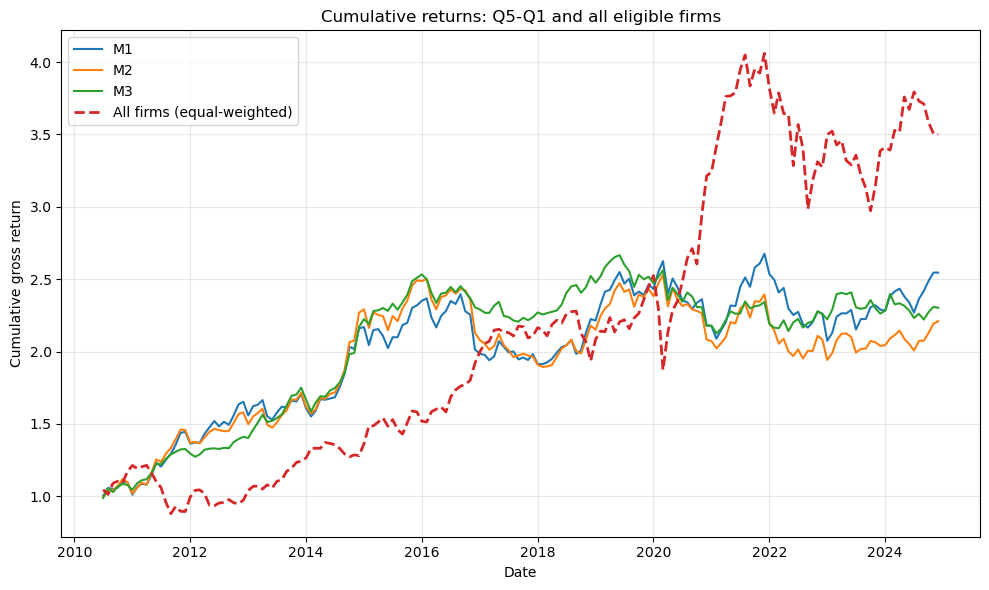

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Q5-Q1 by method
# -----------------------------
plot_df = portfolio_returns_all[portfolio_returns_all["Quintile"] == "Q5-Q1"].copy()
plot_df = plot_df.sort_values(["Method", "HoldDate"])

plt.figure(figsize=(10, 6))

for method, sub in plot_df.groupby("Method"):
    sub = sub.sort_values("HoldDate").copy()
    sub["cumret"] = (1 + sub["ew_ret"]).cumprod()
    plt.plot(sub["HoldDate"], sub["cumret"], label=method)

# -----------------------------
# Mean return of all eligible firms
# -----------------------------
all_firms = returns_panel.dropna(subset=["HoldDate", "ret"]).copy()

all_firms_mean = (
    all_firms.groupby("HoldDate")
    .agg(mean_ret_all_firms=("ret", "mean"),
         n_firms=("Ticker", "nunique"))
    .reset_index()
    .sort_values("HoldDate")
)

all_firms_mean["cumret"] = (1 + all_firms_mean["mean_ret_all_firms"]).cumprod()

plt.plot(
    all_firms_mean["HoldDate"],
    all_firms_mean["cumret"],
    label="All firms (equal-weighted)",
    linewidth=2,
    linestyle="--"
)

plt.title("Cumulative returns: Q5-Q1 and all eligible firms")
plt.xlabel("Date")
plt.ylabel("Cumulative gross return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()